# 使用するライブラリの読み込み

In [1]:
import pandas as pd
import numpy as np
import glob
from datetime import timedelta
import pickle

import chainer
import chainer.functions as F
import chainer.links as L
from chainer import serializers

# テーブルの読み込み

In [210]:
start = 2025
end = 2025

## レース結果の読み込み

In [211]:
def makedataRaceResults(prefix,dataUpdate=False):
    """
    レース結果のデータを作成する関数  
    rowdataに更新があった場合は,`dataUpdate=True`を指定
    """

    raceResults = pd.DataFrame()
    
    if dataUpdate == True:#データに更新があった場合はrowdataを読み込む
        for year in range(start,end + 1):
            files = glob.glob(f"../data/rawData/raceResults/{year}*")
            files.sort()

            cnt = 1
            for file in files:
                print("\r" + "(" + str(cnt) + "/" + str(len(files)) + ")",end="")

                dftmp = pd.read_pickle(file)
                raceResults = pd.concat([raceResults,dftmp])

                cnt += 1
            
            print("\r" + f"{year}年の{cnt}レースの結果を読み込みました")

        raceResults.to_pickle(f"../data/tmpData/{prefix}raceResults.pickle")
    else:
        raceResults = pd.read_pickle(f"../data/tmpData/{prefix}raceResults.pickle")

    return raceResults

In [212]:
raceResults = makedataRaceResults(prefix="betTest",dataUpdate=True)

2025年の1728レースの結果を読み込みました


## レース情報の読み込み

In [213]:
def makedataRaceInfos(prefix,dataUpdate=False):
    """
    レース情報のデータを作成する関数  
    rowdataに更新があった場合は,`dataUpdate=True`を指定
    """
    
    raceInfos = pd.DataFrame()

    if dataUpdate == True:#データの更新があった場合はrawdataを読み込む
        for year in range(start,end + 1):
            #読み込み対象ファイルリストの作成
            files = glob.glob(f"../data/rawData/raceInfos/{year}*")
            files.sort()

            #データの読み込み
            cnt = 1
            for file in files:
                print("\r" + "(" + str(cnt) + "/" + str(len(files)) + ")",end="")

                dftmp = pd.read_pickle(file)
                raceInfos = pd.concat([raceInfos,dftmp])

                cnt += 1
            
            print("\r" + f"{year}年の{cnt}レースの結果を読み込みました")

        raceInfos.to_pickle(f"../data/tmpData/{prefix}raceInfos.pickle")
    else:
        raceInfos = pd.read_pickle(f"../data/tmpData/{prefix}raceInfos.pickle")

    return raceInfos


In [214]:
raceInfos = makedataRaceInfos(prefix="betTest",dataUpdate=True)

2025年の1728レースの結果を読み込みました


## 馬の過去成績の読み込み

In [ ]:
def makedataHorseResults(prefix,dataUpdate=False):
    """
    馬の過去成績のデータを作成する関数  
    rowdataに更新があった場合は,`dataUpdate=True`を指定  
    `horseIDList`の作成に`raceResults`を使用するため、事前に作成の必要あり
    """

    horseResults = pd.DataFrame()

    if dataUpdate == True:
        #horseIDListの作成
        horseIDList = raceResults["horseID"].unique()
        horseIDList.sort()

        cnt = 1
        for horseID in horseIDList:
            try:
                print("\r" + "(" + str(cnt) + "/" + str(len(horseIDList)) + ")",end="")

                dftmp = pd.read_pickle(f"../data/rawData/horse/{horseID}.pickle")

                indexdf = []
                for i in range(len(dftmp)):
                    indexdf.append(horseID)

                dftmp.index = indexdf
                horseResults = pd.concat([horseResults,dftmp])
                cnt += 1
            except FileNotFoundError:
        
        horseResults.to_pickle(f"../data/tmpData/{prefix}horseResults.pickle")
        print("\r" + f"horseResultsは{len(horseResults)}レコードです")

    else:
        horseResults = pd.read_pickle(f"../data/tmpData/{prefix}horseResults.pickle")

    return horseResults

In [218]:
horseIDList = raceResults["horseID"].unique()

In [221]:
horseIDList[5344]

'2021102392'

In [231]:
pd.read_pickle(f"../data/rawData/horse/{2023110066}.pickle")

,日付,開催,天 気,R,レース名,...,馬体重,厩舎 ｺﾒﾝﾄ,備考,勝ち馬 (2着馬),賞金


In [216]:
horseResults = makedataHorseResults(prefix="betTest",dataUpdate=True)

(144/8538)

C:\Users\cyank\AppData\Local\Temp\ipykernel_25684\2052790938.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  horseResults = pd.concat([horseResults,dftmp])


(514/8538)

C:\Users\cyank\AppData\Local\Temp\ipykernel_25684\2052790938.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  horseResults = pd.concat([horseResults,dftmp])


(1002/8538)

...

C:\Users\cyank\AppData\Local\Temp\ipykernel_25684\2052790938.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  horseResults = pd.concat([horseResults,dftmp])


(7633/8538)

C:\Users\cyank\AppData\Local\Temp\ipykernel_25684\2052790938.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  horseResults = pd.concat([horseResults,dftmp])


(7636/8538)

KeyboardInterrupt: 

## 馬の血統情報の読み込み

In [ ]:
def makedataHorsePED(prefix,dataUpdate=False):
    """
    馬の血統情報のデータを作成する関数  
    rowdataに更新があった場合は,`dataUpdate=True`を指定  
    `horseIDList`の作成に`raceResults`を使用するため、事前に作成の必要あり
    """
    horsePED = pd.DataFrame()

    if dataUpdate == True:
        #horseIDListの作成
        horseIDList = raceResults["horseID"].unique()
        horseIDList.sort()

        cnt = 1
        for horseID in horseIDList:
            print("\r" + "(" + str(cnt) + "/" + str(len(horseIDList)) + ")",end="")

            dftmp = pd.read_pickle(f"../data/rawData/ped/{horseID}.pickle")
            horsePED =  pd.concat([horsePED,dftmp])
            cnt += 1

        horsePED.to_pickle(f"../data/tmpData/{prefix}horsePED.pickle")
        print("\n" + f"horsePEDは{len(horsePED)}レコードです")
    else:
        horsePED = pd.read_pickle(f"../data/tmpData/{prefix}horsePED.pickle")

    return horsePED

In [ ]:
horsePED = makedataHorsePED(prefix="betTest",dataUpdate=True)

(5561/5561)
horsePEDは5561レコードです


# 前処理/変数作成

In [ ]:
raceResults = raceResults.rename(columns={
    "着 順":"着順",
    "枠 番":"枠番",
    "馬 番":"馬番",
    "人 気":"人気"})

In [ ]:
horseResults = horseResults.rename(columns={
    "天 気":"天気",
    "映 像":"映像",
    "頭 数":"頭数",
    "枠 番":"枠番",
    "馬 番":"馬番",
    "オ ッ ズ":"オッズ",
    "人 気":"人気",
    "着 順":"着順",
    "斤 量":"斤量",
    "馬場":"馬場",
    "馬場 指数":"馬場指数",
    "ﾀｲﾑ 指数":"タイム指数",
    "厩舎 ｺﾒﾝﾄ":"厩舎コメント",
    "勝ち馬 (2着馬)":"勝ち馬(2着馬)"})

In [ ]:
raceResultsAdd = raceResults.merge(raceInfos, left_on = "raceID", right_on = "raceID", how = "inner")

In [ ]:
def raceResultsPreProcessing(results):
    df = results.copy()
    
    #着順 → Rank
    df["Rank"] = df["着順"].astype(str).str.strip("()降再")
    df = df[df["Rank"].astype(str).str.contains("\d")]
    df["Rank"] = df["Rank"].astype(int)
    
    #性齢 → Sex/Age
    df["Sex"] = df["性齢"].astype(str).str[:1]
    df["Age"] = df["性齢"].str.extract(r'(\d+)').astype(int)
    
    #馬体重 →Weight/WeightVariation
    df = df[df["馬体重"].astype(str).str.contains("\d")]
    df["Weight"] = df["馬体重"].str.split("(",expand=True)[0].astype(int)
    df["WeightVariation"] = df["馬体重"].str.split("(",expand=True)[1].str[:-1].astype(int)
    
    #変数の型を修正
    df["単勝"] = df["単勝"].astype(float)
    df["斤量"] = df["斤量"].astype(int)
    df["人気"] = df["人気"].astype(int)
    df["枠番"] = df["枠番"].astype(int)
    df["馬番"] = df["馬番"].astype(int)
    df["course_len"] = df["course_len"].astype(int)
    df["date"] = pd.to_datetime(df["date"],format="%Y年%m月%d日")
    #不要変数の削除
    df.drop(columns=["タイム","着差","調教師","騎手","馬名","着順","性齢","馬体重"], inplace=True)
    
    return df

raceResultsFin = raceResultsPreProcessing(raceResultsAdd)

In [ ]:
def horseResultsPreProcessing(horseResults):
    df = horseResults.copy()

    #着順 → Rank
    df["Rank"] = df["着順"].astype(str).str.strip("()降再")
    df = df[df["Rank"].astype(str).str.contains("\d")]
    df["Rank"] = df["Rank"].astype(float)
    df["Rank"] = df["Rank"].astype(int)

    #変数の型を修正
    df["date"] = pd.to_datetime(df["日付"])

    #不要変数の削除
    df.drop(columns=["着順","日付"], inplace=True)

    return df

horseResultsFin = horseResultsPreProcessing(horseResults)

In [ ]:
def makeVarFromHorseResults(dftmp):
    """
    馬の過去成績から変数を作成し、dftmpに指定したテーブルに追加する関数  
    作成変数===================  
    pre1Rank  :前1走の順位  
    pre2Rank  :前2走の順位  
    pre3Rank  :前3走の順位  
    pre4Rank  :前4走の順位  
    pre5Rank  :前5走の順位  
    preAllRank:過去すべての順位の平均  
    pre1Term  :前1走から今回までの期間(日)  
    pre2Term  :前2走から前1走までの期間(日)  
    pre3Term  :前3走から前2走までの期間(日)  
    pre4Term  :前4走から前3走までの期間(日)  
    pre5Term  :前5走から前4走までの期間(日)
    """
    dftgt = dftmp.copy()
    #レース結果テーブルからのindexをカラムhorseIDとして取得
    #dftgt.reset_index(inplace= True)
    #dftgt = dftgt.rename(columns={'index': 'raceID'})

    dftmpFin = dftgt.copy()

    #過去の順位系の変数作成===================================================================================================
    #pre1Rank,pre2Rank,pre3Rank,preAllRankMean

    #馬結果テーブルを中央の結果のみにする
    forPreRank = horseResultsFin[horseResultsFin['開催'].str.contains("札幌|函館|福島|新潟|東京|中山|中京|京都|阪神|小倉")]
    #レース結果テーブルと馬結果テーブルを結合(Rank,date,)
    forPreRank2 = dftgt.merge(forPreRank[["Rank","date"]], left_on = "horseID", right_index = True, how = "left")
    #対象レースより過去の日付の結果のみに絞る
    forPreRank2 = forPreRank2[forPreRank2["date_x"] > forPreRank2["date_y"]]
    #レースID,horseIDをキーに連番をふる(何個前のレースかの番号)
    forPreRank2["no"] = forPreRank2.groupby(["raceID","horseID"]).cumcount()

    #過去レースの順位テーブルを作成
    for i in range(5):
        preRankTmp = pd.DataFrame()
        preRankTmp = forPreRank2[forPreRank2["no"] == i][["raceID","horseID","Rank_y"]]
        preRankTmp.rename(columns={'Rank_y': f'pre{str(i + 1)}Rank'},inplace=True)
        dftmpFin = dftmpFin.merge(preRankTmp, left_on=["raceID","horseID"],right_on=["raceID","horseID"],how="left")

    preAllRankMean = forPreRank2.groupby(["raceID","horseID"]).mean("Rank_y")
    preAllRankMean.rename(columns={"Rank_y":"preAllRankMean"},inplace=True)
    dftmpFin = dftmpFin.merge(preAllRankMean["preAllRankMean"],left_on=["raceID","horseID"],right_index=True,how="left")
    #過去実績のない馬に対する処理を追加する必要あり

    #過去のレース間日数系の変数作成============================================================================================
    #pre1Term,pre2Term,pre3Term
    #レース結果テーブルと馬結果テーブルを結合(Rank,date,)
    forPreTerm = dftgt.merge(horseResultsFin[["Rank","date"]], left_on = "horseID", right_index = True, how = "left")
    #対象レースより過去の日付の結果のみに絞る
    forPreTerm = forPreTerm[forPreTerm["date_x"] > forPreTerm["date_y"]]
    #レースID,horseIDをキーに連番をふる(何個前のレースかの番号)
    forPreTerm["no"] = forPreTerm.groupby(["raceID","horseID"]).cumcount()

    #過去のレース間の日数を算出
    preTermFin = pd.DataFrame()
    termColumnsList = ["raceID","horseID"]
    for i in range(5):
        preTermTmp = forPreTerm[forPreTerm["no"] == i][["raceID","horseID","date_x","date_y"]]
        preTermTmp.rename(columns={"date_y":f"pre{str(i + 1)}date"},inplace=True)

        if i == 0 :
            preTermFin = preTermTmp
            preTermFin.rename(columns={"date_x":"pre0date"},inplace=True)
        else:
            preTermFin = preTermFin.merge(preTermTmp[["raceID","horseID",f"pre{str(i + 1)}date"]],left_on=["raceID","horseID"],right_on=["raceID","horseID"],how="left")

        preTermFin[f"pre{str(i + 1)}Term"] = preTermFin[f"pre{str(i)}date"] - preTermFin[f"pre{str(i + 1)}date"]
        preTermFin[f"pre{str(i + 1)}Term"] = preTermFin[f"pre{str(i + 1)}Term"] / timedelta(days=1)
        termColumnsList.append(f"pre{str(i + 1)}Term")

    #dftmpにレース間日数情報を結合
    dftmpFin = dftmpFin.merge(preTermFin[termColumnsList],left_on=["raceID","horseID"],right_on=["raceID","horseID"],how="left")

    return dftmpFin

betTestDF = makeVarFromHorseResults(raceResultsFin)

In [ ]:
#一旦保存
betTestDF.to_pickle("../data/forModeling/betTestDF.pickle")

In [ ]:
pd.set_option('display.max_columns', betTestDF.shape[1])
betTestDF

,枠番,馬番,斤量,単勝,人気,raceID,horseID,jockeyID,raceName,course_len,weather,raceType,groundState,date,Rank,Sex,Age,Weight,WeightVariation,pre1Rank,pre2Rank,pre3Rank,pre4Rank,pre5Rank,preAllRankMean,pre1Term,pre2Term,pre3Term,pre4Term,pre5Term
0,4,7,56,7.6,3,202505010101,2022104967,01184,3歳未勝利,1400,晴,ダート,良,2025-02-01,1,牡,3,504,12,8.0,NaN,NaN,NaN,NaN,8.000000,90.0,NaN,NaN,NaN,NaN
1,2,4,57,10.5,5,202505010101,2022106071,01150,3歳未勝利,1400,晴,ダート,良,2025-02-01,2,牡,3,502,8,7.0,5.0,NaN,NaN,NaN,6.000000,98.0,12.0,NaN,NaN,NaN
2,5,10,57,71.9,9,202505010101,2022110025,01092,3歳未勝利,1400,晴,ダート,良,2025-02-01,3,牡,3,464,-12,9.0,9.0,NaN,NaN,NaN,9.000000,70.0,63.0,NaN,NaN,NaN
3,6,12,56,233.5,11,202505010101,2022107130,01192,3歳未勝利,1400,晴,ダート,良,2025-02-01,4,牡,3,464,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8,16,54,9.7,4,202505010101,2022100749,01214,3歳未勝利,1400,晴,ダート,良,2025-02-01,5,牡,3,500,-4,5.0,2.0,6.0,4.0,NaN,4.250000,69.0,14.0,15.0,12.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7604,1,1,53,15.5,8,202510011012,2021101825,01212,4歳以上1勝クラス,1200,曇,芝,良,2025-02-23,14,牝,4,446,2,3.0,11.0,12.0,1.0,4.0,5.769231,21.0,70.0,71.0,56.0,7.0
7605,4,7,53,348.8,18,202510011012,2019105765,01195,4歳以上1勝クラス,1200,曇,芝,良,2025-02-23,15,牝,6,468,4,17.0,14.0,10.0,13.0,13.0,11.153846,84.0,42.0,71.0,112.0,34.0
7606,3,5,56,110.4,14,202510011012,2020100997,01096,4歳以上1勝クラス,1200,曇,芝,良,2025-02-23,16,牝,5,486,12,14.0,7.0,12.0,3.0,13.0,8.000000,106.0,20.0,63.0,22.0,56.0
7607,2,3,54,14.5,7,202510011012,2020102208,01183,4歳以上1勝クラス,1200,曇,芝,良,2025-02-23,17,牝,5,456,-6,2.0,9.0,3.0,6.0,6.0,5.714286,22.0,84.0,20.0,56.0,21.0


In [ ]:
infoDF = betTestDF[[
    "raceID",
    "馬番",
    "horseID",
    "jockeyID",
    "date",
    "単勝"
]].copy()

In [ ]:
betTestDF = betTestDF[[
    '枠番',
    '馬番', 
    '斤量',
    '単勝',
    '人気',
    'course_len',
    'weather',
    'raceType',
    'groundState',
    'Sex',
    'Age',
    'Weight',
    'WeightVariation',
    'pre1Rank',
    'pre2Rank',
    'pre3Rank',
    'pre4Rank',
    'pre5Rank',
    'preAllRankMean',
    'pre1Term',
    'pre2Term',
    'pre3Term',
    'pre4Term',
    'pre5Term']]

In [ ]:
#labelEncoding
categorical_features = ["weather","raceType","groundState","Sex"]
for col in categorical_features:
    with open(f"../data/labelencoder/{col}_labelEncoder.pickle","rb") as f:
        LE = pickle.load(f)

    #LE.classes_ = np.append(LE.classes_,np.nan)
    betTestDF[col] = LE.transform(betTestDF[col])
    betTestDF[col] = betTestDF[col].astype("category")

#欠損値補完
betTestDF = betTestDF.fillna({
    "枠番":-1,
    "馬番":-1,
    "Weight":-1,
    "WeightVariation":-1,
    "pre1Rank":-1,
    "pre2Rank":-1,
    "pre3Rank":-1,
    "pre4Rank":-1,
    "pre5Rank":-1,
    "preAllRankMean":-1,
    "pre1Term":-1,
    "pre2Term":-1,
    "pre3Term":-1,
    "pre4Term":-1,
    "pre5Term":-1})

C:\Users\cyank\AppData\Local\Temp\ipykernel_25684\3276766577.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  betTestDF[col] = LE.transform(betTestDF[col])
C:\Users\cyank\AppData\Local\Temp\ipykernel_25684\3276766577.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  betTestDF[col] = betTestDF[col].astype("category")
C:\Users\cyank\AppData\Local\Temp\ipykernel_25684\3276766577.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col

# 予測

## モデルのロード

### lightGBMモデルのロード

In [ ]:
with open("../models/lightGBM/LGBM_1.pickle", "rb") as f:
        modelLGBM = pickle.load(f)

### NNモデルのロード

In [ ]:
class Mychain(chainer.Chain):
    def __init__(self):
        super().__init__(
            bn = L.BatchNormalization(24),
            l1 = L.Linear(None, 24),
            l2 = L.Linear(None, 12),
            l3 = L.Linear(None, 6),
            l4 = L.Linear(None, 2),
        )

    def __call__(self,x):
        h1 = F.relu(self.l1(self.bn(x)))
        h2 = F.relu(self.l2(h1))
        h3 = F.relu(self.l3(h2))
        output = self.l4(h3)

        return output
    
model = L.Classifier(Mychain())
serializers.load_npz("../models/neuralNetwork/NN_1.npz",model)

## 予測値付与

### lightGBMによるスコアリング

In [ ]:
socredDataLGBM = modelLGBM.predict(betTestDF)
infoDF["predLGBM"] = socredDataLGBM

### NNによるスコアリング

In [ ]:
forScoring_x = betTestDF.values
forScoring_x = forScoring_x.astype(np.float32)

In [ ]:
socredDataNN = F.softmax(model.predictor(forScoring_x).data)[:,1].array
infoDF["predNN"] = socredDataNN

In [ ]:
pd.set_option('display.max_columns', infoDF.shape[1])
infoDF.head(16)

,raceID,馬番,horseID,jockeyID,date,単勝,predLGBM,predNN
0,202505010101,7,2022104967,01184,2025-02-01,7.6,0.305054,0.427509
1,202505010101,4,2022106071,01150,2025-02-01,10.5,0.281927,0.265918
2,202505010101,10,2022110025,01092,2025-02-01,71.9,0.067247,0.070218
3,202505010101,12,2022107130,01192,2025-02-01,233.5,0.015225,0.012133
4,202505010101,16,2022100749,01214,2025-02-01,9.7,0.300812,0.423716
5,202505010101,2,2022104847,01122,2025-02-01,2.8,0.683110,0.674330
6,202505010101,15,2022104095,00422,2025-02-01,30.1,0.140947,0.136855
7,202505010101,14,2022103030,01043,2025-02-01,642.9,0.002456,0.000564
8,202505010101,13,2022103556,01180,2025-02-01,21.3,0.161286,0.189944
9,202505010101,8,2022110064,05386,2025-02-01,2.6,0.605518,0.615301


# 払い戻しシミュレーション

## 払い戻しテーブルの読み込み

In [96]:
from tqdm.notebook import tqdm
import math

In [50]:
raceIDList = infoDF["raceID"].unique()
len(raceIDList)

returnTables = pd.DataFrame()

for raceID in tqdm(raceIDList):
    tmpdf = pd.read_pickle(f"../data/rawData/return/{raceID}.pickle")
    returnTables = pd.concat([returnTables,tmpdf])

  0%|          | 0/528 [00:00<?, ?it/s]

## 賭ける対象の馬を抽出

In [182]:
#予測値の上位n等を対象とする
def maketgthorseList(rank, colname,rankname):
    tmpdf = infoDF.copy()
    tmpdf[rankname] = tmpdf.groupby(["raceID"])[colname].rank(ascending=False)
    tmpdf = tmpdf[tmpdf[rankname] <= rank]
    return tmpdf

#予測値が閾値を超えたら対象とする。
def maketgthorseListThreshold(threshold, colname):
    tmpdf = infoDF.copy()
    tmpdf = tmpdf[tmpdf[colname] >= threshold]
    return tmpdf

In [175]:
lgbmR3DF = maketgthorseList(5,"predLGBM","predLGBM_rank")
nnR3DF = maketgthorseList(3,"predNN","predNN_rank")

In [199]:
lgbmR3DF = maketgthorseListThreshold(0.5,"predLGBM")

## 掛け金を設定

In [200]:
def betConstReturn(tgtDF,returns):
    tgtDF["bet"] = returns / tgtDF["単勝"]
    tgtDF["bet"] = tgtDF["bet"].apply(lambda x: math.ceil(x/100)*100)

In [201]:
betConstReturn(lgbmR3DF,5000)

## 払い戻し情報の付与

In [202]:
def makeReturn(tgtdf,bettingHow):
    if bettingHow == "単勝":
        tgtreturnTable = returnTables[returnTables["betting"] == bettingHow]
        tgtreturnTable["馬番"] = tgtreturnTable["results"].astype(int)
        tgtreturnTable = tgtreturnTable[["raceID","馬番","payoutRate"]]

    tmpdf = tgtdf.merge(tgtreturnTable, on = ["raceID","馬番"] , how = "left")
    tmpdf = tmpdf.fillna({"payoutRate":0})
    tmpdf["return"] = tmpdf["bet"] * tmpdf["payoutRate"]
    tmpdf["return"] = tmpdf["return"].astype(int)

    return tmpdf

In [203]:
lgbmsimu = makeReturn(lgbmR3DF,"単勝")

C:\Users\cyank\AppData\Local\Temp\ipykernel_25684\3252388843.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tgtreturnTable["馬番"] = tgtreturnTable["results"].astype(int)


In [207]:
lgbmsimu_sum = lgbmsimu.groupby(["date"])[["bet","return"]].sum()
lgbmsimu_sum["profit"] = lgbmsimu_sum["return"] - lgbmsimu_sum["bet"]
lgbmsimu_sum["profitCumsum"] = lgbmsimu_sum["profit"].cumsum()

In [208]:
lgbmsimu_sum

,bet,return,profit,profitCumsum
date,,,,
2025-01-05,52800,30360,-22440,-22440
2025-01-06,60500,25529,-34971,-57411
2025-01-11,56000,61430,5430,-51981
2025-01-12,68700,66290,-2410,-54391
2025-01-13,49500,41130,-8370,-62761
2025-01-18,65000,61840,-3160,-65921
2025-01-19,65500,46420,-19080,-85001
2025-01-25,108500,117870,9370,-75631
2025-01-26,109400,102919,-6481,-82112


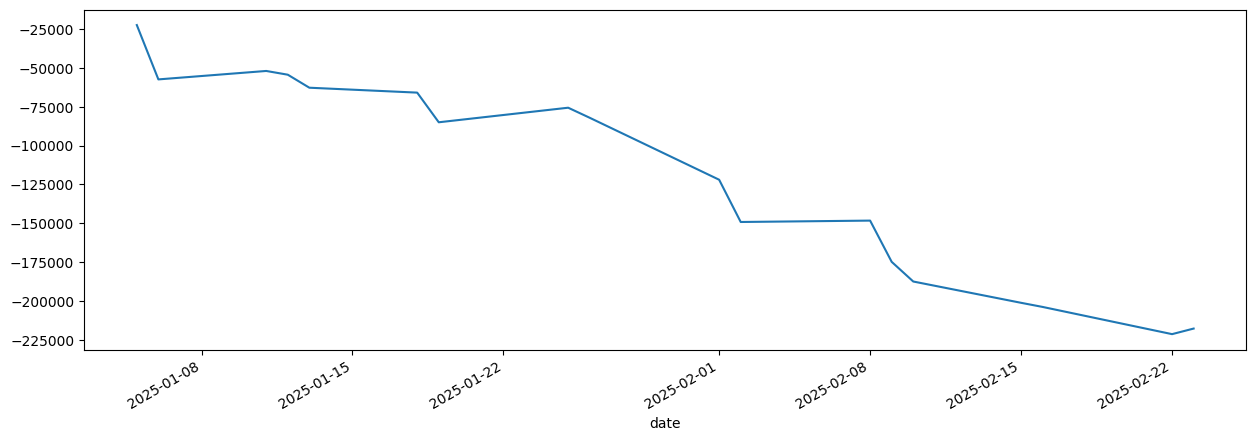

In [209]:
lgbmsimu_sum["profitCumsum"].plot(figsize=(15,5))
plt.show()